In [28]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/dataset/ST010003.png
/kaggle/input/dataset/EH00040000.png
/kaggle/input/dataset/CN00020003.png
/kaggle/input/dataset/GM00050001.png
/kaggle/input/dataset/CN00020000.png
/kaggle/input/dataset/CN00020001.png
/kaggle/input/dataset/GM00050000.png
/kaggle/input/dataset/LN00030003.png
/kaggle/input/dataset/EH00040002.png
/kaggle/input/dataset/EH00040001.png
/kaggle/input/dataset/GM00050002.png
/kaggle/input/dataset/ST010001.png
/kaggle/input/dataset/EH00040003.png
/kaggle/input/dataset/CN00020002.png
/kaggle/input/dataset/LN00030002.png
/kaggle/input/dataset/GM00050003.png
/kaggle/input/dataset/LN00030001.png
/kaggle/input/dataset/LN00030000.png
/kaggle/input/dataset/ST010002.png
/kaggle/input/dataset/ST010000.png
/kaggle/input/tfrecordmodel/tensorflow2/default/1/unet-tpu.h5
/kaggle/input/tfrecordmodel/tensorflow2/default/1/tfrecordcrops-tpu-unetf.weights.h5


In [29]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Conv2DTranspose, concatenate

def conv_block(input, num_filters):
    conv = Conv2D(num_filters, (3, 3), activation="relu", padding="same", kernel_initializer='he_normal')(input)
    conv = Conv2D(num_filters, (3, 3), activation="relu", padding="same", kernel_initializer='he_normal')(conv)
    return conv

def encoder_block(input, num_filters):
    conv = conv_block(input, num_filters)
    pool = MaxPooling2D((2, 2))(conv)
    return conv, pool

def decoder_block(input, skip_features, num_filters):
    uconv = Conv2DTranspose(num_filters, (2, 2), strides=2, padding="same")(input)
    con = concatenate([uconv, skip_features])
    conv = conv_block(con, num_filters)
    return conv

def unet_model(input_shape):
    input_layer = Input(input_shape)
    
    s1, p1 = encoder_block(input_layer, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    b1 = conv_block(p4, 1024)

    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)
    
    output_layer = Conv2D(1, 1, padding="same", activation="sigmoid")(d4)

    model = Model(input_layer, output_layer, name="U-Net")
    return model

In [30]:
model = unet_model(input_shape=(256, 256, 1))
model.load_weights("/kaggle/input/tfrecordmodel/tensorflow2/default/1/tfrecordcrops-tpu-unetf.weights.h5")
print("Weights loaded successfully")

Weights loaded successfully


In [31]:
import tensorflow as tf
import matplotlib.pyplot as plt

def load_and_preprocess_image(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=1)           # Grayscale
    img = tf.image.resize(img, [256, 256])               # Resize to match model input
    img = tf.image.convert_image_dtype(img, tf.float32)  # Normalize to [0, 1]
    img = tf.expand_dims(img, axis=0)                    # Add batch dimension
    return img

image_path = "/kaggle/input/dataset/ST010000.png"
input_image = load_and_preprocess_image(image_path)

In [32]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def predict_full_image_mask(model, image_path, n=4, out_size=256):
    """
    Predicts a full-size mask for an image using patch-wise inference.

    Args:
        model: Trained Keras model.
        image_path (str): Path to the input image.
        n (int): Grid divisions (n x n crops).
        out_size (int): Size to resize each crop for the model input.

    Returns:
        img_np (np.ndarray): Original grayscale image.
        final_mask (np.ndarray): Predicted binary mask with same shape as image.
    """
    # Load image
    img = Image.open(image_path).convert("L")
    img_np = np.array(img)
    original_h, original_w = img_np.shape

    # Pad to make divisible by n
    pad_h = (n - original_h % n) % n
    pad_w = (n - original_w % n) % n
    padded_img = np.pad(img_np, ((0, pad_h), (0, pad_w)), mode='constant', constant_values=0)

    padded_h, padded_w = padded_img.shape
    step_h, step_w = padded_h // n, padded_w // n

    # Create full-size padded mask
    full_mask = np.zeros((padded_h, padded_w), dtype=np.float32)

    # Predict on each crop
    for i in range(n):
        for j in range(n):
            y_start = i * step_h
            x_start = j * step_w

            crop = padded_img[y_start:y_start + step_h, x_start:x_start + step_w]
            resized_crop = cv2.resize(crop, (out_size, out_size))
            input_crop = resized_crop[np.newaxis, ..., np.newaxis] / 255.0  # Normalize

            pred = model.predict(input_crop, verbose=0)[0, ..., 0]
            pred_resized = cv2.resize(pred, (step_w, step_h))  # Resize back

            full_mask[y_start:y_start + step_h, x_start:x_start + step_w] = pred_resized

    # Crop back to original image size
    final_mask = full_mask[:original_h, :original_w]

    return img_np, final_mask

In [33]:
from PIL import Image

def display_and_save_mask(predicted_mask, n, save_dir="/kaggle/working"):
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"predicted_mask_n{n}.png")

    # Save using PIL without resizing or cropping
    Image.fromarray((predicted_mask * 255).astype(np.uint8)).save(save_path)

    # Optional: still show with matplotlib
    plt.figure(figsize=(6, 6))
    plt.imshow(predicted_mask, cmap="gray", vmin=0, vmax=1)
    plt.axis("off")
    plt.show()

    print(f"Saved predicted mask to: {save_path}")

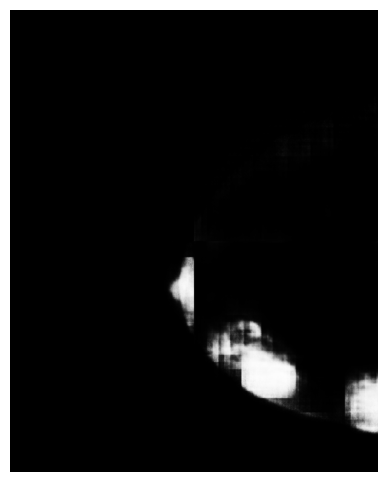

Saved predicted mask to: /kaggle/working/predicted_mask_n2.png


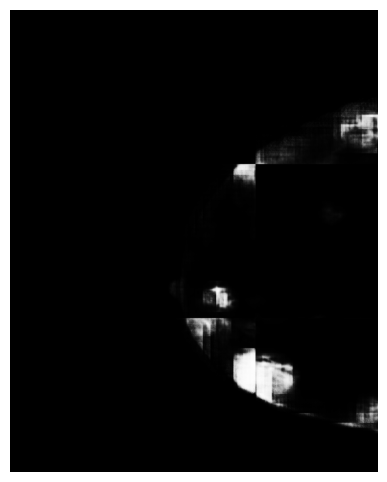

Saved predicted mask to: /kaggle/working/predicted_mask_n3.png


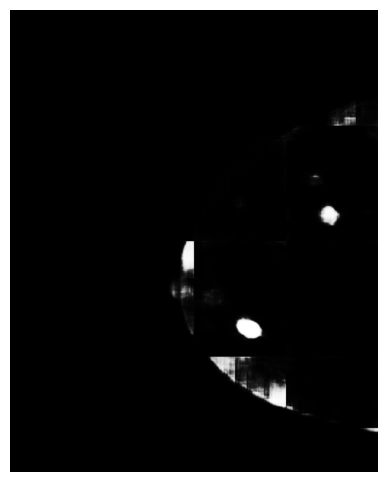

Saved predicted mask to: /kaggle/working/predicted_mask_n4.png


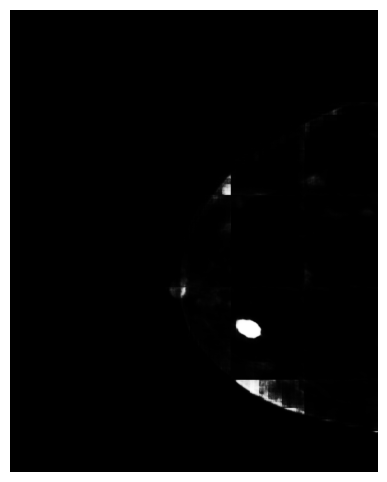

Saved predicted mask to: /kaggle/working/predicted_mask_n5.png


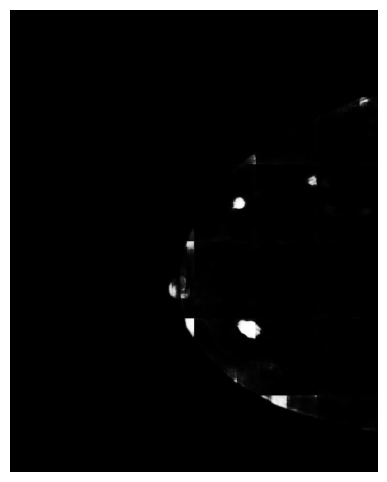

Saved predicted mask to: /kaggle/working/predicted_mask_n6.png


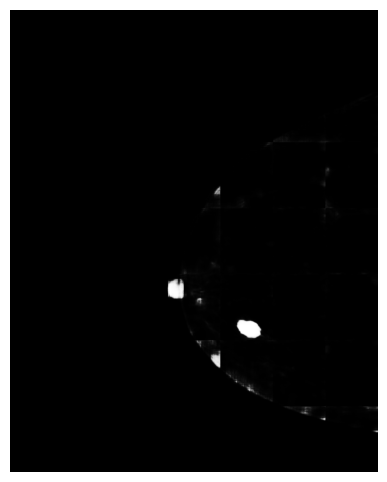

Saved predicted mask to: /kaggle/working/predicted_mask_n7.png


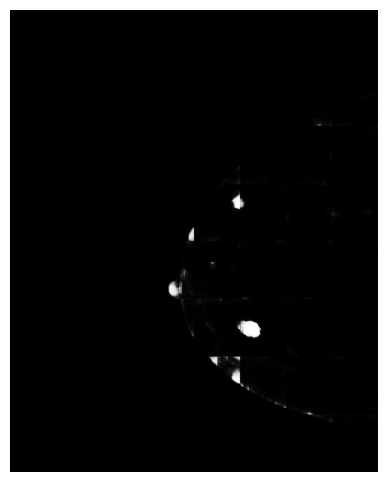

Saved predicted mask to: /kaggle/working/predicted_mask_n8.png


In [34]:
for n in range(2, 9):
    img_np, pred_mask = predict_full_image_mask(model, image_path, n=n)
    display_and_save_mask(pred_mask, n=n)

Combined mask shape: (3518, 2800)


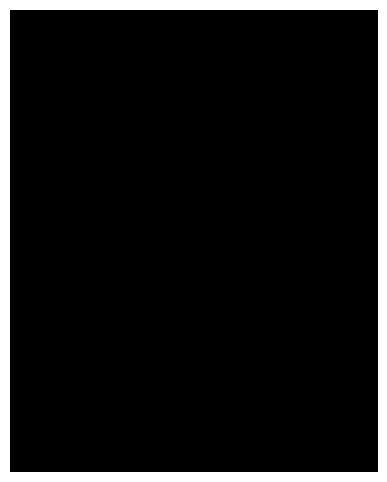

In [35]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import Image as IPyImage, display

# Set your directory
base_dir = "/kaggle/working"

# Collect all mask grid images
mask_files = [f"predicted_mask_n{n}.png" for n in range(2, 9)]
mask_paths = [os.path.join(base_dir, f) for f in mask_files if os.path.exists(os.path.join(base_dir, f))]

# Load and stack all masks as binary (0 or 1)
mask_stack = []

for path in mask_paths:
    mask_img = Image.open(path).convert("L")
    mask_array = np.array(mask_img) / 255.0  # Normalize to 0 or 1
    binary_mask = (mask_array > 0.5).astype(np.uint8)  # Threshold to 0/1
    mask_stack.append(binary_mask)

# Compute the pixel-wise AND (intersection): Only keep white if all are white
combined_mask = np.min(np.stack(mask_stack, axis=0), axis=0)  # shape: (H, W)
print("Combined mask shape:", combined_mask.shape)

# Display the result
plt.figure(figsize=(6, 6))
plt.imshow(combined_mask, cmap="gray")
#plt.title("Combined Mask (AND across n=2 to 10)")
plt.axis("off")
#plt.show()

# Save safely preserving original shape
combined_path = os.path.join(base_dir, "combined_mask_intersection.png")
Image.fromarray((combined_mask * 255).astype(np.uint8)).save(combined_path)

In [36]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import Image as IPyImage, display

def combine_masks_by_pixel_count_threshold(base_dir="/kaggle/working", n_range=range(2, 9), threshold=6):
    # Collect all mask paths
    mask_files = [f"predicted_mask_n{n}.png" for n in n_range]
    mask_paths = [os.path.join(base_dir, f) for f in mask_files if os.path.exists(os.path.join(base_dir, f))]

    if not mask_paths:
        print("No predicted mask files found.")
        return

   # print(f"Found {len(mask_paths)} mask files.")

    # Load and binarize masks
    mask_stack = []
    for path in mask_paths:
        mask_img = Image.open(path).convert("L")
        mask_array = np.array(mask_img) / 255.0
        binary_mask = (mask_array > 0.5).astype(np.uint8)
        mask_stack.append(binary_mask)

    mask_stack = np.stack(mask_stack, axis=0)  # Shape: (num_masks, H, W)

    # Count how many times each pixel is white
    white_pixel_count = np.sum(mask_stack, axis=0)

 #   print("White pixel count per pixel:")
  #  print("Min:", white_pixel_count.min(), "Max:", white_pixel_count.max())
  #  print("Applying threshold:", threshold)

    # Create final mask: white if pixel is white in ≥ threshold masks
    final_mask = (white_pixel_count >= threshold).astype(np.uint8)

    # Save safely preserving original shape
    combined_path = os.path.join(base_dir, f"combined_mask_thresholded{threshold}.png")
    Image.fromarray((final_mask * 255).astype(np.uint8)).save(combined_path)

    print(f"Combined mask saved to: {combined_path}")

        
    # Display the result
    plt.figure(figsize=(6, 6))
    plt.imshow(final_mask, cmap="gray")
    #plt.title("Combined Mask (AND across n=2 to 10)")
    plt.axis("off")

Combined mask saved to: /kaggle/working/combined_mask_thresholded3.png
Combined mask saved to: /kaggle/working/combined_mask_thresholded4.png
Combined mask saved to: /kaggle/working/combined_mask_thresholded5.png
Combined mask saved to: /kaggle/working/combined_mask_thresholded6.png
Combined mask saved to: /kaggle/working/combined_mask_thresholded7.png
Combined mask saved to: /kaggle/working/combined_mask_thresholded8.png
Combined mask saved to: /kaggle/working/combined_mask_thresholded9.png


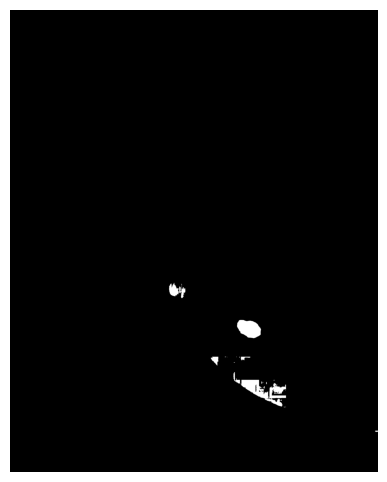

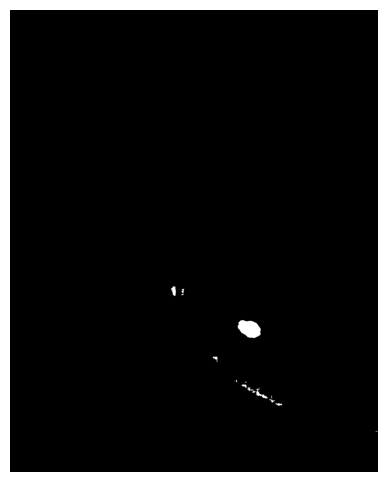

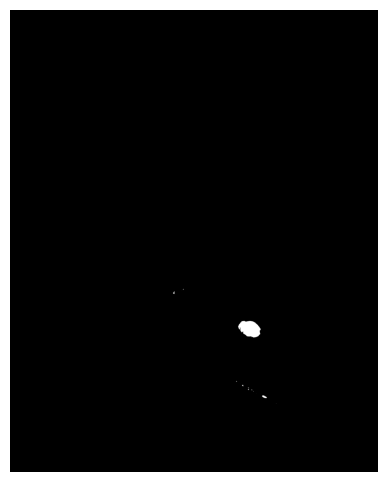

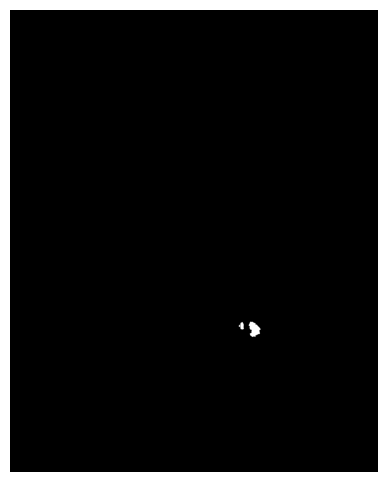

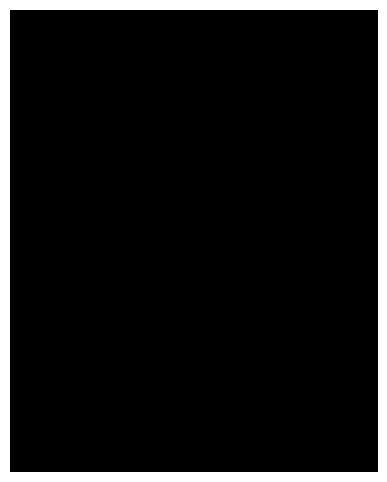

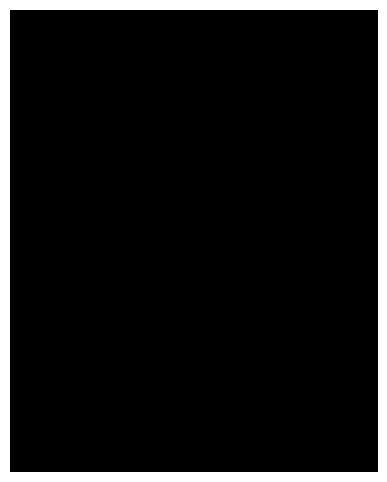

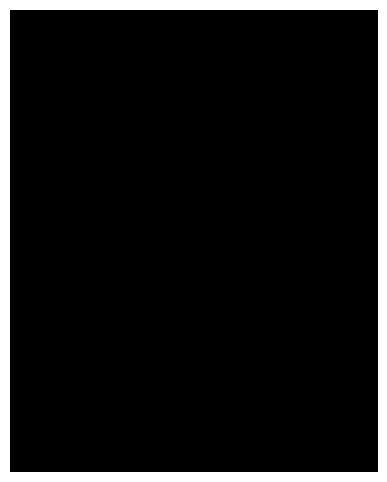

In [37]:
combine_masks_by_pixel_count_threshold(threshold=3)
combine_masks_by_pixel_count_threshold(threshold=4)
combine_masks_by_pixel_count_threshold(threshold=5)
combine_masks_by_pixel_count_threshold(threshold=6)
combine_masks_by_pixel_count_threshold(threshold=7)
combine_masks_by_pixel_count_threshold(threshold=8)
combine_masks_by_pixel_count_threshold(threshold=9)

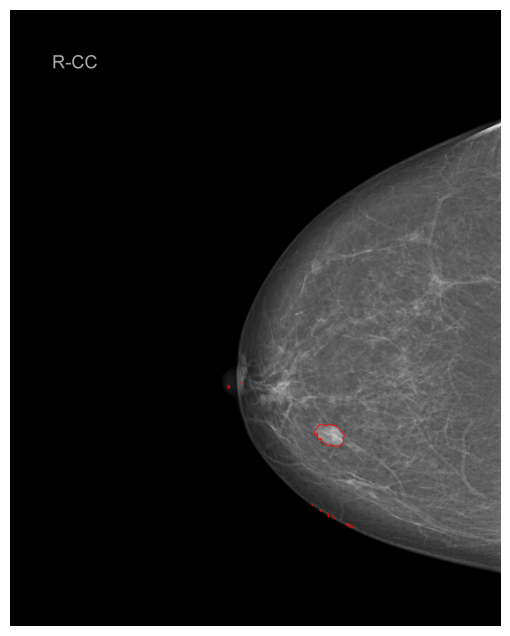

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load original image
orig_img = Image.open(image_path).convert("RGB")  # Use "RGB" for OpenCV, not "RGBA"
orig_img_np = np.array(orig_img)                  # Convert to NumPy array

# Load the mask image (must be grayscale or binary for contours)
mask = Image.open('/kaggle/working/combined_mask_thresholded5.png').convert("L")
mask_np = np.array(mask)

# Find contours (boundaries) in mask
contours, _ = cv2.findContours(mask_np, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours on original image (color=red, thickness=3)
contour_img = orig_img_np.copy()
cv2.drawContours(contour_img, contours, -1, (255, 0, 0), 3)  # Red outline

# Display result
plt.figure(figsize=(8,8))
plt.imshow(contour_img)
plt.axis('off')
plt.show()